
# Voting Paradoxes in Four Candidate Elections — Figure Reproduction

This notebook redraws **Figures 1–5** of Gupta, Malakar & Sinha (2018),
*"Voting Paradoxes in Four Candidate Elections"*, using the same
geometric construction already verified against the paper's tables in
`voting_paradoxes.py` (see `Voting_Paradoxes_Replication.ipynb`).

| Figure | What it shows | Underlying table |
|---|---|---|
| 1 | Saari triangle for 3 candidates: outer triangle, medians, the no-SCW region G-D-H, and the OWNCM region I-J-K | Table 4 |
| 2 | Full tetrahedron for 4 candidates (A "on top"): midpoints, face-BCD construction (X, Y), and the alpha_A=0.5 plane (X', Y') | — (construction figure) |
| 3 | Case (a) region: outer tetrahedron X'Y'-B'C'-O and the inner, centroid-sharing OWNCM tetrahedron X''Y''-B''C''-O' | Table 5 |
| 4 | Tetrahedron for 4 candidates redrawn with D "on top": construction of Q, R, S, P | — (construction figure) |
| 5 | Case (b) region: outer tetrahedron P-Q-R-S and the inner OWNCM tetrahedron P'-Q'-R'-S' | Table 6 |

**Approach.** `voting_paradoxes_figures.py` computes every labeled point
using the exact same `centroid` / `shrink` helper functions (and, for
Figures 3 and 5, the exact same vertex definitions) already used and
verified in `voting_paradoxes.py`. Nothing is re-derived independently
here — this notebook is purely about turning already-verified points into
pictures, and each figure includes a numeric print-out confirming its key
coordinates against the corresponding table.

3-candidate points are plotted in a 2D equilateral triangle (matching the
paper's Figure 1 layout). 4-candidate points are plotted in a 3D
tetrahedron rendered with matplotlib's 3D toolkit, oriented to match each
figure's described "vertex on top" layout in the paper.


In [1]:

import sys
sys.path.insert(0, '.')
import matplotlib.pyplot as plt
%matplotlib inline

from voting_paradoxes import geometric_bounds_3, geometric_bounds_4
from voting_paradoxes_figures import (
    figure1_points, plot_figure1,
    figure2_points, plot_figure2,
    figure3_points, plot_figure3,
    figure4_points, plot_figure4,
    figure5_points, plot_figure5,
)
print('Libraries loaded OK.')


Libraries loaded OK.



## Figure 1 — The Saari triangle (3 candidates)

Outer triangle A-B-C; the three medians (dashed) all meet at the centroid
H; the green triangle G-D-H is the region with no Strong Condorcet Winner
and α<sub>A</sub> > α<sub>B</sub> > α<sub>C</sub>; the red triangle I-J-K
(sharing the same centroid P, at half the linear scale) is the OWNCM
(Condorcet-Paradox-likely) region whose vertex coordinates give Table 4's
vote-share bounds.


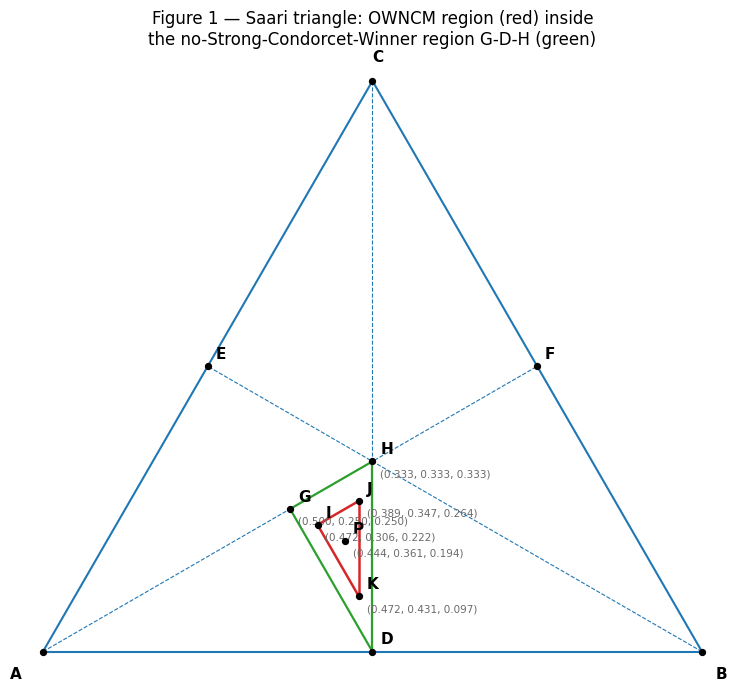

In [2]:

fig1 = plot_figure1()
plt.show()


In [3]:

pts = figure1_points()
print('Key Figure 1 coordinates (alpha_A, alpha_B, alpha_C):')
for lab in ['H', 'G', 'P', 'I', 'J', 'K']:
    a, b, c = pts[lab]
    print(f'  {lab}: ({float(a):.4f}, {float(b):.4f}, {float(c):.4f})')

# Cross-check against Table 4 (via geometric_bounds_3, already verified in
# the tables notebook)
bounds = geometric_bounds_3()
print()
print('Table 4 bounds derived from I, J, K above:')
for lab, (lo, hi) in bounds.items():
    print(f'  {lab}: {lo:.4f} - {hi:.4f}')


Key Figure 1 coordinates (alpha_A, alpha_B, alpha_C):
  H: (0.3333, 0.3333, 0.3333)
  G: (0.5000, 0.2500, 0.2500)
  P: (0.4444, 0.3611, 0.1944)
  I: (0.4722, 0.3056, 0.2222)
  J: (0.3889, 0.3472, 0.2639)
  K: (0.4722, 0.4306, 0.0972)

Table 4 bounds derived from I, J, K above:
  A: 0.3889 - 0.4722
  B: 0.3056 - 0.4306
  C: 0.0972 - 0.2639



## Figure 2 — Tetrahedron construction for 4 candidates

The full tetrahedron A-B-C-D (A "on top", matching the paper's own
orientation), its six edge midpoints, the construction on face B-C-D
(points X, Y, where α<sub>A</sub>=0), and the construction on the plane
where α<sub>A</sub>=0.5 (points X', Y', built from the AB/AC/AD midpoints).
This is the setup figure the paper uses before deriving the Case (a) /
Case (b) sub-regions in Figures 3 and 5.


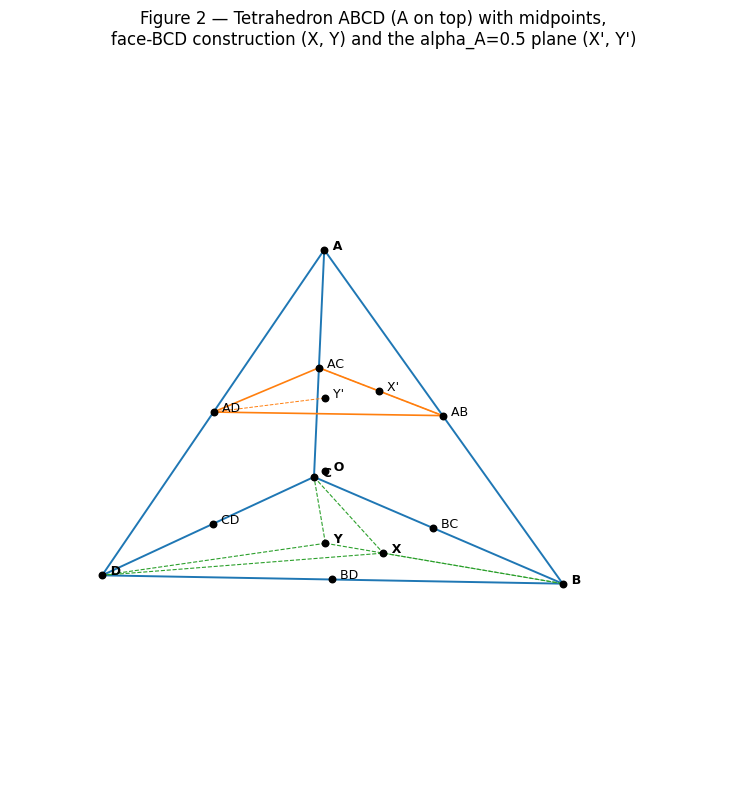

In [4]:

fig2 = plot_figure2()
plt.show()


In [5]:

pts = figure2_points()
print('Key Figure 2 coordinates (alpha_A, alpha_B, alpha_C, alpha_D):')
for lab in ['X', 'Y', "X'", "Y'", 'O']:
    a, b, c, d = pts[lab]
    print(f'  {lab}: ({float(a):.4f}, {float(b):.4f}, {float(c):.4f}, {float(d):.4f})')


Key Figure 2 coordinates (alpha_A, alpha_B, alpha_C, alpha_D):
  X: (0.0000, 0.5000, 0.2500, 0.2500)
  Y: (0.0000, 0.3333, 0.3333, 0.3333)
  X': (0.5000, 0.2500, 0.2500, 0.0000)
  Y': (0.5000, 0.1667, 0.1667, 0.1667)
  O: (0.2500, 0.2500, 0.2500, 0.2500)



## Figure 3 — Case (a): α<sub>A</sub>+α<sub>D</sub> > α<sub>B</sub>+α<sub>C</sub>

The outer tetrahedron X'-Y'-B'C'-O (blue) is the region satisfying Case
(a). The inner tetrahedron X''-Y''-B''C''-O' (red) — similar to the outer
one, sharing the same centroid G1, at the linear scale
(372/1296)<sup>1/3</sup> — is the OWNCM region. Its vertices' vote-share
bounds are exactly Table 5.


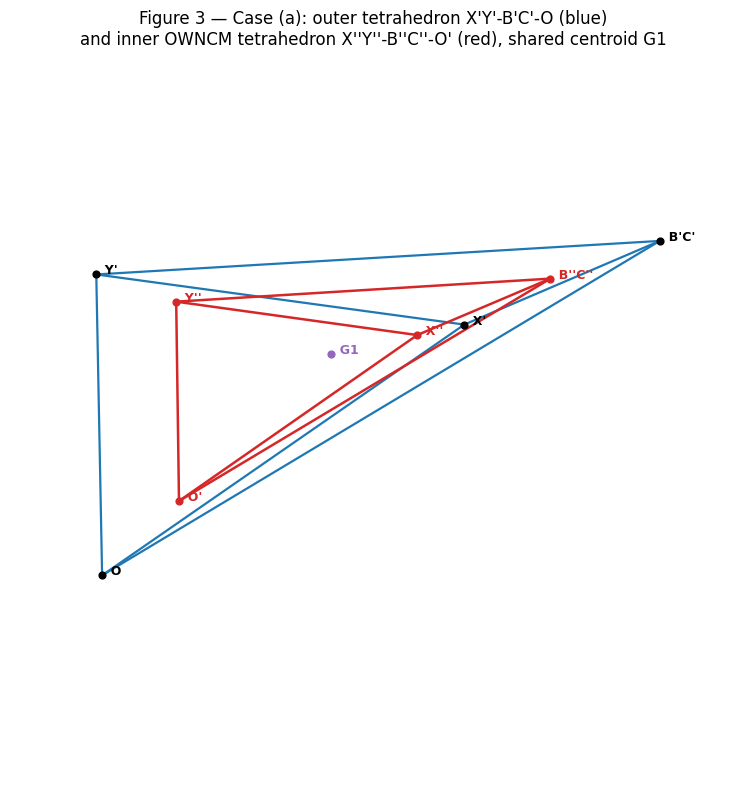

In [6]:

fig3 = plot_figure3()
plt.show()


In [7]:

outer, inner, G1 = figure3_points()
print("Inner tetrahedron X''Y''-B''C''-O' coordinates (should match Table 5's derivation):")
for lab, pt in inner.items():
    print(f'  {lab}: ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f}, {pt[3]:.4f})')

bounds5 = geometric_bounds_4('a')
print()
print('Table 5 bounds derived from these vertices:')
for lab, (lo, hi) in bounds5.items():
    print(f'  {lab}: {lo:.4f} - {hi:.4f}')


Inner tetrahedron X''Y''-B''C''-O' coordinates (should match Table 5's derivation):
  X'': (0.4787, 0.2429, 0.1498, 0.1285)
  Y'': (0.4787, 0.1879, 0.1773, 0.1560)
  B''C'': (0.4787, 0.2429, 0.2323, 0.0461)
  O': (0.3138, 0.2429, 0.2323, 0.2110)

Table 5 bounds derived from these vertices:
  A: 0.3138 - 0.4787
  B: 0.1879 - 0.2429
  C: 0.1498 - 0.2323
  D: 0.0461 - 0.2110



## Figure 4 — Tetrahedron construction for 4 candidates, Case (b) orientation

The same tetrahedron A-B-C-D, redrawn with D "on top" (as the paper does
for the Case (b) discussion), showing the construction of Q (midpoint of
A, B), R (centroid of A, B, C), S (midpoint of Q and the A-C midpoint),
and P (centroid of the whole tetrahedron).


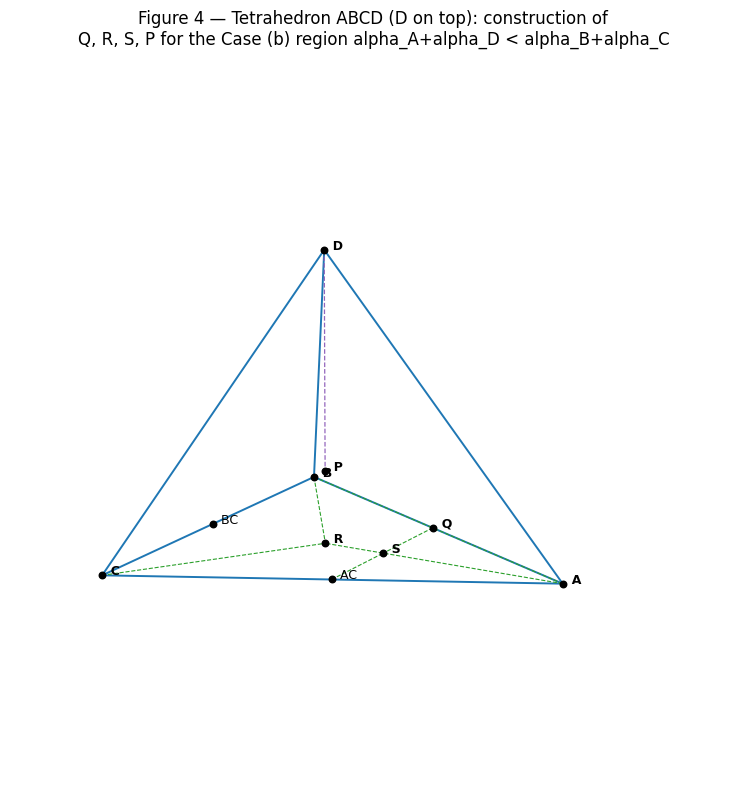

In [8]:

fig4 = plot_figure4()
plt.show()


In [9]:

pts = figure4_points()
print('Key Figure 4 coordinates (alpha_A, alpha_B, alpha_C, alpha_D):')
for lab in ['Q', 'R', 'S', 'P']:
    a, b, c, d = pts[lab]
    print(f'  {lab}: ({float(a):.4f}, {float(b):.4f}, {float(c):.4f}, {float(d):.4f})')


Key Figure 4 coordinates (alpha_A, alpha_B, alpha_C, alpha_D):
  Q: (0.5000, 0.5000, 0.0000, 0.0000)
  R: (0.3333, 0.3333, 0.3333, 0.0000)
  S: (0.5000, 0.2500, 0.2500, 0.0000)
  P: (0.2500, 0.2500, 0.2500, 0.2500)



## Figure 5 — Case (b): α<sub>A</sub>+α<sub>D</sub> < α<sub>B</sub>+α<sub>C</sub>

The outer tetrahedron P-Q-R-S (blue) is the region satisfying Case (b).
The inner tetrahedron P'-Q'-R'-S' (red) — similar to the outer one,
sharing the same centroid G2, at the linear scale (384/1296)<sup>1/3</sup>
(= 2/3 exactly) — is the OWNCM region. Its vertices' vote-share bounds are
exactly Table 6.


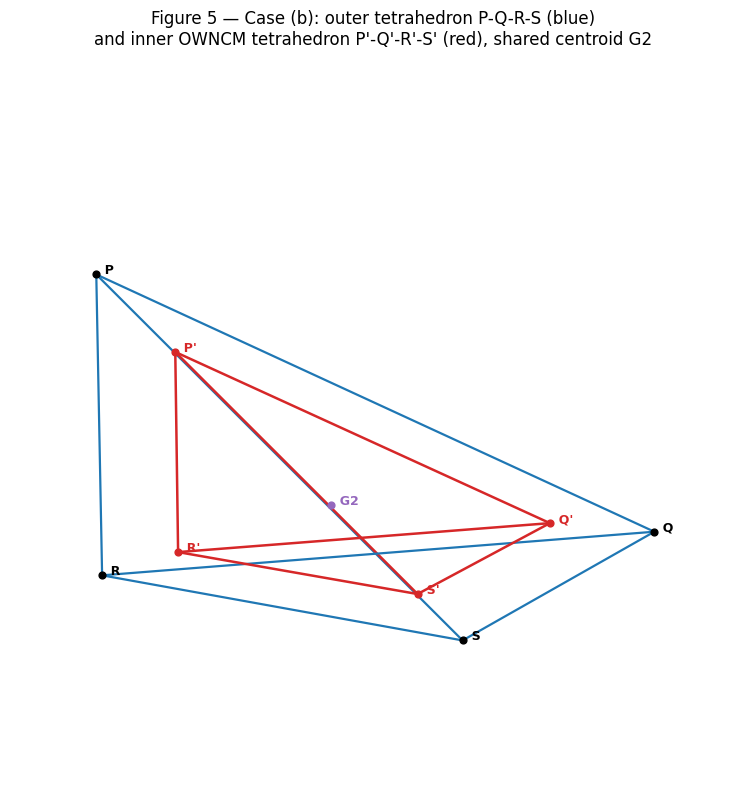

In [10]:

fig5 = plot_figure5()
plt.show()


In [11]:

outer, inner, G2 = figure5_points()
print("Inner tetrahedron P'Q'R'S' coordinates (should match Table 6's derivation):")
for lab, pt in inner.items():
    print(f'  {lab}: ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f}, {pt[3]:.4f})')

bounds6 = geometric_bounds_4('b')
print()
print('Table 6 bounds derived from these vertices:')
for lab, (lo, hi) in bounds6.items():
    print(f'  {lab}: {lo:.4f} - {hi:.4f}')


Inner tetrahedron P'Q'R'S' coordinates (should match Table 6's derivation):
  P': (0.2986, 0.2778, 0.2361, 0.1875)
  Q': (0.4653, 0.4444, 0.0694, 0.0208)
  R': (0.3542, 0.3333, 0.2917, 0.0208)
  S': (0.4653, 0.2778, 0.2361, 0.0208)

Table 6 bounds derived from these vertices:
  A: 0.2986 - 0.4653
  B: 0.2778 - 0.4444
  C: 0.0694 - 0.2917
  D: 0.0208 - 0.1875



## Notes on this reproduction

- All five figures are built from the **same exact-`Fraction` vertex
  definitions** used in `voting_paradoxes.py`'s `geometric_bounds_3` /
  `geometric_bounds_4`, which are independently verified against Tables
  4, 5, and 6 in the companion notebook. The numeric print-outs above
  confirm the figures and tables agree to 4 decimal places.
- The 4-candidate figures (2, 3, 4, 5) are true 3D tetrahedra rendered
  with matplotlib's 3D toolkit and a fixed regular-tetrahedron embedding
  (one vertex "up", the other three forming a base triangle), rotated
  per-figure to put the vertex the paper emphasizes ("A on top" for
  Figures 2/3, "D on top" for Figures 4/5) at the apex — a plotting choice
  only, matching the paper's illustrations, and not a change to any
  underlying coordinate.
- Figure 1's labels **L** and **M**, shown in the original PDF as
  unlabeled intersection points inside the G-D-H triangle (with no
  coordinates given anywhere in the paper's text), are omitted here since
  they carry no independently defined value to verify — everything with a
  stated coordinate in the paper (H, G, P, I, J, K) is reproduced exactly.
